Estimated Parameters:
R0_init: 2.0516489609913684, kint: 0.0, tint: 67.58211068666016, delta_t: 19.879099567377235, r: 10.0


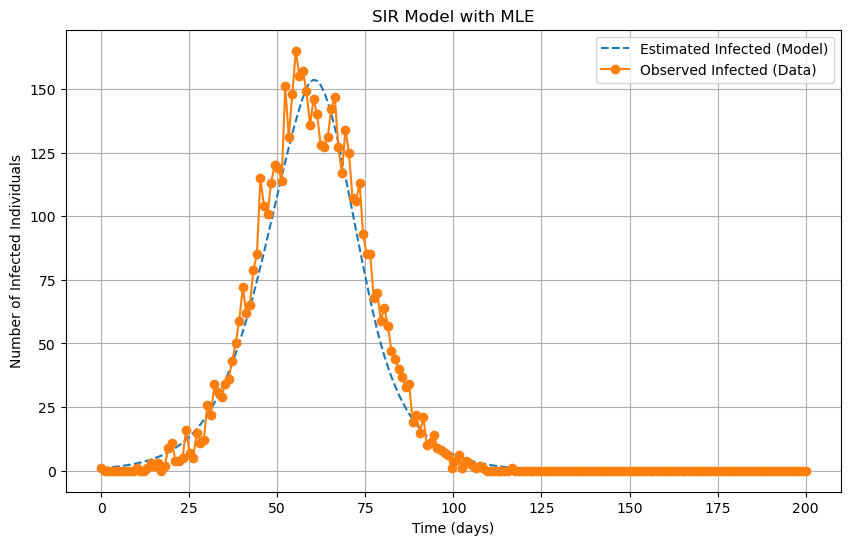

In [79]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.stats import nbinom
from scipy.optimize import minimize

# Define the piecewise R0(t)
def R0_piecewise(t, R0_init, kint, tint, delta_t):
    if t <= tint - 0.5 * delta_t:
        return R0_init
    elif tint - 0.5 * delta_t < t <= tint + 0.5 * delta_t:
        return R0_init - (R0_init - kint * R0_init) * ((t - (tint - 0.5 * delta_t)) / delta_t)
    else:
        return kint * R0_init

# Define the SIR model equations
def sir_model(y, t, R0_init, kint, tint, delta_t, gamma, N):
    S, I, R = y
    R0_current = R0_piecewise(t, R0_init, kint, tint, delta_t)
    dS_dt = -R0_current * gamma * S * I / N
    dI_dt = R0_current * gamma * S * I / N - gamma * I
    dR_dt = gamma * I
    return [dS_dt, dI_dt, dR_dt]

# Negative Binomial likelihood function
def negative_binomial_likelihood(I_data, I_model, r):
    likelihoods = nbinom.pmf(I_data, r, r / (r + I_model))
    return -np.sum(np.log(likelihoods + 1e-9))  # Use log to prevent underflow; +1e-9 for stability

# Define the objective function for optimization
def mle_objective(params, t, I_data, N, gamma):
    R0_init, kint, tint, delta_t, r = params
    S0 = N - I_data[0]
    I0 = I_data[0]
    R0 = 0
    initial_conditions = [S0, I0, R0]
    
    # Simulate the SIR model
    solution = odeint(sir_model, initial_conditions, t, args=(R0_init, kint, tint, delta_t, gamma, N))
    S, I_model, R = solution.T
    
    # Calculate the negative log likelihood
    neg_log_likelihood = negative_binomial_likelihood(I_data, I_model, r)
    return neg_log_likelihood


# Define a function to generate a synthetic outbreak curve
def generate_synthetic_outbreak(t, peak_day=60, peak_cases=1000, spread=15):
    """
    Generates synthetic outbreak data resembling a typical infectious disease curve.
    Parameters:
        t: Array of time points.
        peak_day: Day when the peak occurs.
        peak_cases: Number of cases at the peak.
        spread: Controls the width of the outbreak (how quickly it rises and falls).
    Returns:
        Array of daily case counts.
    """
    # Use a Gaussian-like function for the outbreak curve
    I_data = peak_cases * np.exp(-0.5 * ((t - peak_day) / spread) ** 2)
    I_data = np.random.poisson(I_data)  # Add some randomness to simulate real data noise
    return I_data

# Generate the synthetic outbreak data
I_data = generate_synthetic_outbreak(t, peak_day=60, peak_cases=150, spread=15)

# Define the parameters for the SIR model
gamma = 1 / 10  # Recovery rate
N = 1000  # Population size

# Example time points and observed data (replace with actual data)
t = np.linspace(0, 200, 200)


# Initial guesses for the parameters
initial_guess = [2.5, 0.5, 50, 20, 5]  # [R0_init, kint, tint, delta_t, r]

# Perform optimization using MLE
result = minimize(mle_objective, initial_guess, args=(t, I_data, N, gamma), 
                  bounds=[(0, 5), (0, 1), (0, len(t)), (0, len(t)), (1e-3, 10)], 
                  method='L-BFGS-B')

# Extract estimated parameters
R0_est, kint_est, tint_est, delta_t_est, r_est = result.x
print("Estimated Parameters:")
print(f"R0_init: {R0_est}, kint: {kint_est}, tint: {tint_est}, delta_t: {delta_t_est}, r: {r_est}")

# Simulate the SIR model with estimated parameters
S0 = N - I_data[0]
initial_conditions = [S0, I_data[0], 0]
solution_estimated = odeint(sir_model, initial_conditions, t, args=(R0_est, kint_est, tint_est, delta_t_est, gamma, N))
S_est, I_est, R_est = solution_estimated.T

# Plot the estimated model against observed data
plt.figure(figsize=(10, 6))
plt.plot(t, I_est, label='Estimated Infected (Model)', linestyle='--')
plt.plot(t, I_data, label='Observed Infected (Data)', marker='o')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Individuals')
plt.title('SIR Model')
plt.legend()
plt.grid()
plt.show()

